In [1]:
!pip install -q tf_keras_vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.9 MB/s eta 0:00:00


> ResSplit-KAN: A Self-Explainable Kolmogorov–Arnold Network–Integrated Custom Residual Split Multi-Scale Lightweight Model for Acute Lymphoblastic Leukemia Classification

In [2]:
# === System & OS Utilities ===
import os
import sys
import math
import pickle
import random
import warnings
warnings.filterwarnings("ignore")

# === Progress Bar ===
from tqdm import tqdm

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras import Model, Input, layers, initializers
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adamax, AdamW
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, Dense, Dropout, Flatten, Layer,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    MaxPooling2D, BatchNormalization, ReLU,
    Add, Reshape, Multiply, Activation, Concatenate
)
from tensorflow.keras.utils import register_keras_serializable, plot_model

# === Data Handling ===
import numpy as np
import pandas as pd
import cv2

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# === Scikit-learn ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

import matplotlib
import sklearn

2025-11-27 08:40:43.663285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764232843.904558      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764232843.968339      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow version: 2.18.0
Keras version: 3.8.0
NumPy version: 1.26.4
Pandas version: 2.2.3
OpenCV version: 4.12.0
Matplotlib version: 3.7.2
Seaborn version: 0.12.2
Scikit-learn version: 1.2.2


In [4]:
#python version 3.11.11
#!python -m pip install tensorflow==2.18.0 keras==3.5.0 numpy==1.26.4 pandas==2.2.3 opencv-python==4.6.0.66 matplotlib==3.7.5 seaborn==0.12.2 scikit-learn==1.2.2

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPUs detected.")

GPUs detected: 1


In [6]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCH = 100
img_shape=(*IMG_SIZE,3)
dataset_path = r"/kaggle/input/pbs-3242-normalized-resized-aug-8k-datasets/PBS-3242-Normalized-datasets/HE_Normalized_Dataset"
labels = sorted([d for d in os.listdir(dataset_path) 
                 if os.path.isdir(os.path.join(dataset_path, d))])
print("Class Names:", labels)

Class Names: ['Benign', 'Early Pre-B', 'Pre-B', 'Pro-B']


In [7]:
def data_frame(path):
    class_paths = []
    classes = []

    for label in os.listdir(path):
        class_dir = os.path.join(path, label)
        if os.path.isdir(class_dir):  
            for image in os.listdir(class_dir):
                class_paths.append(os.path.join(class_dir, image))
                classes.append(label)

    df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return df

In [8]:
dataframe = data_frame(dataset_path)
# First split: 70% train, 30% temp (val + test)
train_dataframe, temp_dataframe = train_test_split(
    dataframe,
    test_size=0.3,
    random_state=42,
    stratify=dataframe['Class']
)

# Second split: 2/3 val, 1/3 test of the 30% => 20% val, 10% test overall
validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe,
    test_size=1/3,
    random_state=42,
    stratify=temp_dataframe['Class']
)

print(f"Train size: {len(train_dataframe)}, Validation size: {len(validation_dataframe)}, Test size: {len(test_dataframe)}")

Train size: 5600, Validation size: 1600, Test size: 800


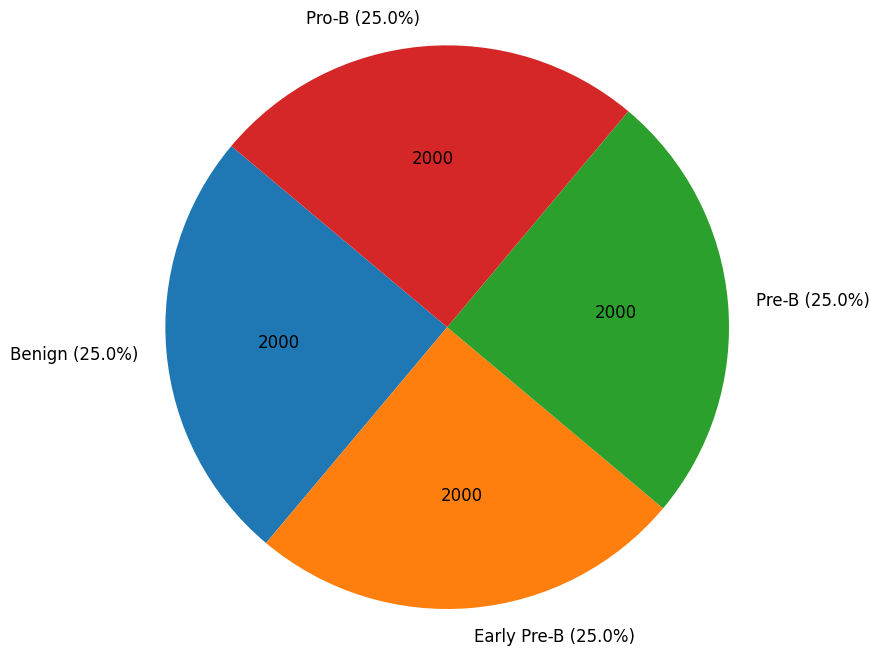

In [9]:
# Count occurrences in each DataFrame
train_counts = train_dataframe['Class'].value_counts()
val_counts = validation_dataframe['Class'].value_counts()
test_counts = test_dataframe['Class'].value_counts()

# Combine and sum the counts
total_counts = train_counts.add(val_counts, fill_value=0)
total_counts = total_counts.add(test_counts, fill_value=0)
total_counts = total_counts.sort_index()

# Prepare labels with percentages
total = total_counts.sum()
labels_with_percent = [f"{label} ({(count/total)*100:.1f}%)" for label, count in zip(total_counts.index, total_counts.values)]

# Define custom autopct function to show raw count
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_counts.values, labels=labels_with_percent, autopct=make_autopct(total_counts.values), startangle=140, textprops={'fontsize': 12})
plt.axis('equal')
plt.show()

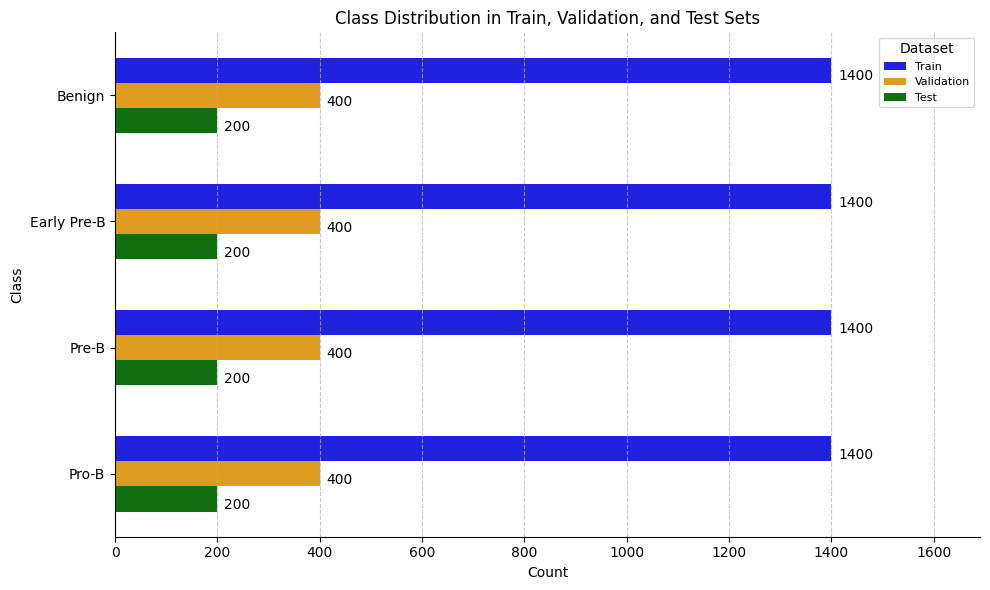

In [10]:
# Count occurrences of each class in train, validation, and test datasets
train_counts = train_dataframe['Class'].value_counts().sort_index()
val_counts = validation_dataframe['Class'].value_counts().sort_index()
test_counts = test_dataframe['Class'].value_counts().sort_index()

# Combine into a DataFrame with the index kept as a column
data_counts = pd.DataFrame({
    'Class': train_counts.index,
    'Train': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values
}).melt(id_vars='Class', var_name='Dataset', value_name='Count')

# Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(y='Class', x='Count', hue='Dataset', data=data_counts, 
                 palette=['blue', 'orange', 'green'], orient='h', width=0.6)

# Add count labels to the right of the bars with slight downward offset
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.0 + 0.05),  # pushed slightly down
                ha='left', va='center', 
                fontsize=10, color='black', 
                xytext=(5, 0), textcoords='offset points')

# Remove borders (spines)
sns.despine(top=True, right=True, left=False, bottom=False)

# Dynamically set the x-axis limits with some extra space on the right
left, right = ax.get_xlim()  # Get current x-limits

# Set the new right limit with a 15% increase
right += (right - left) * 0.15  # Increase right by 15%

# Apply the new limits to the x-axis
ax.set_xlim(left, right)

# Add labels and title
plt.ylabel("Class")
plt.xlabel("Count")
plt.title("Class Distribution in Train, Validation, and Test Sets")

# Move the legend
plt.legend(title="Dataset", loc='upper right', fontsize=8)

# Add grid only along x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tidy layout
plt.tight_layout()
plt.show()

In [11]:
def preprocess_image(image):
    """
    Simple Min-Max Normalization for RGB image.
    Safe for Keras ImageDataGenerator (expects one image at a time).
    Returns float32 image scaled to [0, 1].
    """
    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    # avoid division by zero
    if max_val - min_val < 1e-6:
        return np.zeros_like(image, dtype=np.float32)

    # min-max scale to [0, 1]
    image = (image - min_val) / (max_val - min_val)

    return image


In [12]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image,  # CLAHE preprocessing
    rotation_range=180,          # lesions can be at any orientation
    zoom_range=0.1,              # up to ±10% zoom
    width_shift_range=0.10,      # up to 10% horizontal shift
    height_shift_range=0.10,     # up to 10% vertical shift
    shear_range=0.05,            # very small shear (avoid heavy distortion)
    horizontal_flip=True,        # horizontal flipping image
    vertical_flip=True,          # vertically flipping image
    brightness_range=[0.9, 1.1], # ±10% brightness variation
    fill_mode='nearest',        
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Class Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, shuffle=False, seed=42)

Found 5600 validated image filenames belonging to 4 classes.
Found 1600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [13]:
def _denormalize_for_display(img):
    """
    Convert a preprocessed float image to uint8 for plt.imshow.
    Uses per-image min-max scaling so display is robust.
    """
    im = img.copy().astype(np.float32)
    im_min = float(np.min(im))
    im_max = float(np.max(im))
    if im_max - im_min < 1e-6:
        return np.zeros_like(im, dtype=np.uint8)
    im_out = (im - im_min) / (im_max - im_min)
    im_out = (im_out * 255.0).clip(0, 255).astype(np.uint8)
    return im_out


def show_from_generator(generator, n=5):
    """
    Fetch one batch from a Keras ImageDataGenerator (or Sequence) and show `n` images.
    - Make sure the generator was created AFTER you updated preprocess_image.
    """
    # Get a batch robustly
    try:
        batch = next(generator)
    except TypeError:
        batch = generator[0]
    except StopIteration:
        gen_iter = iter(generator)
        batch = next(gen_iter)

    # handle common batch formats
    if isinstance(batch, (tuple, list)):
        images, labels = batch[0], batch[1] if len(batch) > 1 else None
    elif isinstance(batch, dict):
        images = batch.get("images") or batch.get("x") or batch.get("inputs")
        labels = batch.get("labels") or batch.get("y")
    else:
        raise ValueError("Unsupported batch format from generator")

    images = np.asarray(images)
    n = min(n, len(images))
    plt.figure(figsize=(3 * n, 3))
    for i in range(n):
        img = images[i]
        disp = _denormalize_for_display(img)
        plt.subplot(1, n, i + 1)
        plt.imshow(disp)
        if labels is not None:
            lbl = np.argmax(labels[i]) if getattr(labels, "ndim", 0) > 1 else labels[i]
            plt.title(f"Label: {lbl}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

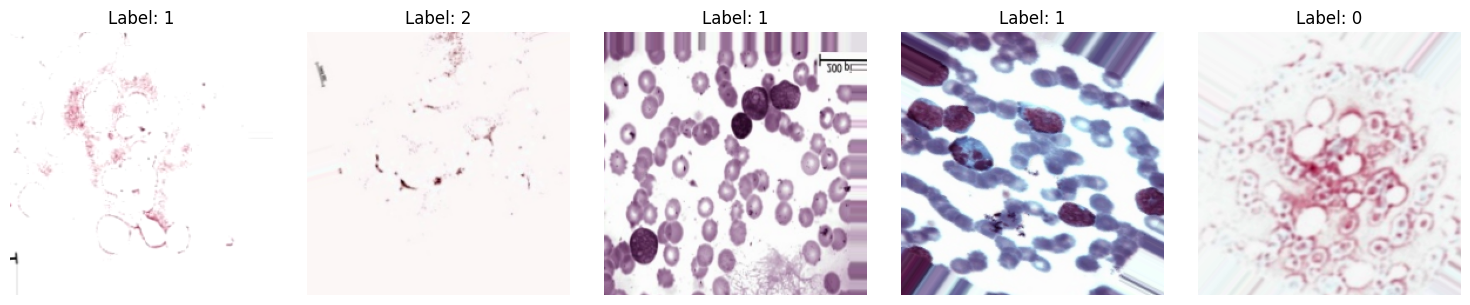

In [14]:
show_from_generator(train_data)

In [15]:
@tf.keras.utils.register_keras_serializable(package="Custom", name="F1Score")
class F1Score(tf.keras.metrics.Metric):
    """
    Custom Keras metric to compute the F1 Score.
    The F1 score is the harmonic mean of precision and recall.
    """

    def __init__(self, name='f1_score', **kwargs):
        """
        Initializes the F1Score metric. 
        - Uses Keras' Precision and Recall metrics as intermediate steps.
        """
        super().__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()  # Precision metric
        self.recall = tf.keras.metrics.Recall()  # Recall metric

    def update_state(self, y_true, y_pred, sample_weight=None):
        """
        Updates the state of the metric.
        - This method is called during training to update precision and recall.
        - The precision and recall states are updated based on true and predicted values.
        """
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        """
        Computes and returns the F1 score.
        - F1 score is calculated as the harmonic mean of precision and recall.
        - Prevents division by zero by adding a small epsilon value to the denominator.
        """
        p = self.precision.result()  # Get precision value
        r = self.recall.result()  # Get recall value
        return 2 * (p * r) / (p + r + tf.keras.backend.epsilon())  # Calculate F1 score

    def reset_states(self):
        """
        Resets the states of the precision and recall metrics.
        - This is called at the beginning of each epoch.
        """
        self.precision.reset_states()  # Reset precision state
        self.recall.reset_states()  # Reset recall state


In [16]:
class RestoreBestValidationModel(Callback):
    """
    Custom Keras Callback to restore model weights from the best epoch based on validation accuracy.
    - Tracks the best validation accuracy during training.
    - Restores the model weights from the epoch with the best validation accuracy when training finishes.
    """
    
    def __init__(self):
        super(RestoreBestValidationModel, self).__init__()
        # Initialize best validation accuracy, epoch, and weights to track the best model
        self.best_val_acc = -1
        self.best_epoch = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        """
        Callback function executed at the end of each epoch.
        - Compares the current validation accuracy with the best validation accuracy.
        - If the current validation accuracy is higher or tied but at a later epoch, updates the best model weights.
        """
        # Get validation accuracy from logs
        val_acc = logs.get('val_accuracy')
        
        if val_acc is not None:
            # Update the best validation accuracy and weights if the current one is better or at a later epoch
            if val_acc > self.best_val_acc or (val_acc == self.best_val_acc and epoch > self.best_epoch):
                self.best_val_acc = val_acc
                self.best_epoch = epoch
                self.best_weights = self.model.get_weights()  # Store the model's weights
                print(f"\nModel weights updated at epoch {epoch + 1} with val_accuracy: {val_acc:.4f}")

    def on_train_end(self, logs=None):
        """
        Callback function executed at the end of training.
        - Restores the model weights from the epoch with the best validation accuracy.
        """
        # If we found a better model during training, restore the best weights
        if self.best_weights is not None:
            print(f"\nRestoring model weights from best epoch {self.best_epoch + 1} with val_accuracy: {self.best_val_acc:.4f}")
            self.model.set_weights(self.best_weights)  # Set the weights back to the best model's weights

# Instantiate the callback
restore_best = RestoreBestValidationModel()


In [17]:
@register_keras_serializable(package="Custom", name="KANLayer")
class KANLayer(Layer):
    def __init__(self, units, grid=5, spline_order=3, dropout=0.0, **kwargs):
        """
        KANLayer: Kernel Attention Network Layer (self-explainable)
        - units: output dimension
        - grid: number of spline bins
        - spline_order: reserved for higher-order splines
        - dropout: dropout rate
        """
        super(KANLayer, self).__init__(**kwargs)
        self.units = int(units)
        self.grid = int(grid)
        self.spline_order = int(spline_order)
        self.dropout = float(dropout)

    def build(self, input_shape):
        if len(input_shape) != 2:
            raise ValueError(f"KANLayer expects 2D input (batch, features). Got shape: {input_shape}")

        input_dim = int(input_shape[-1])

        # Linear weights (like Dense)
        self.w = self.add_weight(
            shape=(input_dim, self.units),
            initializer=initializers.HeNormal(),
            trainable=True,
            name="linear_weight"
        )

        # Spline weights: (grid, input_dim, units)
        self.spline_w = self.add_weight(
            shape=(self.grid, input_dim, self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="spline_weight"
        )

        # Bias
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True,
            name="bias"
        )

        super(KANLayer, self).build(input_shape)

    def call(self, inputs, training=False):
        x = tf.cast(inputs, tf.float32)

        # --- Linear part ---
        linear_out = tf.linalg.matmul(x, self.w)

        # --- Spline / soft-binning part ---
        x_exp = tf.expand_dims(x, axis=1)  # (B, 1, D)

        # Fixed 0-1 grid (assumes input normalized to 0-1)
        grid_centers = tf.linspace(0.0, 1.0, self.grid)
        grid_centers = tf.reshape(grid_centers, (1, self.grid, 1))  # (1, grid, 1)
        grid_centers = tf.cast(grid_centers, tf.float32)

        # Soft RBF-like basis: (B, grid, D)
        spline_basis = tf.exp(-tf.square(x_exp - grid_centers))

        # einsum: "bgd,gdu->bu" -> (B, units)
        spline_out = tf.einsum("bgd,gdu->bu", spline_basis, self.spline_w)

        out = linear_out + spline_out + self.b

        if self.dropout and training:
            out = tf.nn.dropout(out, rate=self.dropout)

        return out

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.units)

    def get_config(self):
        cfg = super(KANLayer, self).get_config()
        cfg.update({
            "units": self.units,
            "grid": self.grid,
            "spline_order": self.spline_order,
            "dropout": self.dropout,
        })
        return cfg

In [18]:
# Channel Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="ChannelAttention")
class ChannelAttention(Layer):
    """
    Channel Attention Block (CA) that computes channel-wise attention.
    
    Args:
        reduction: The factor for reducing the number of channels in the intermediate layer.
    """
    def __init__(self, reduction=16, **kwargs):
        super(ChannelAttention, self).__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        """
        Build the dense layers for the Channel Attention mechanism.
        - `shared_dense_one`: reduces channel dimensions.
        - `shared_dense_two`: restores the original channel dimensions.
        """
        channel = input_shape[-1]  # Number of channels in the input tensor
        self.shared_dense_one = Dense(channel // self.reduction, activation='relu', kernel_initializer='he_normal', use_bias=True)
        self.shared_dense_two = Dense(channel, kernel_initializer='he_normal', use_bias=True)

    def call(self, inputs):
        """
        Apply the Channel Attention mechanism:
        - Global Average Pooling (avg_pool) and Global Max Pooling (max_pool)
        - Process each through a set of shared dense layers.
        - Combine both attentions and apply a sigmoid function to get the attention weights.
        """
        # Global average and max pooling
        avg_pool = GlobalAveragePooling2D()(inputs)
        max_pool = GlobalMaxPooling2D()(inputs)

        # Apply shared dense layers for both average and max pooled features
        avg_pool = self.shared_dense_one(avg_pool)
        avg_pool = self.shared_dense_two(avg_pool)

        max_pool = self.shared_dense_one(max_pool)
        max_pool = self.shared_dense_two(max_pool)

        # Combine both attention signals and apply sigmoid activation
        attention = Add()([avg_pool, max_pool])
        attention = Activation('sigmoid')(attention)

        # Reshape the attention to match the input dimensions and apply multiplication
        attention = Reshape((1, 1, -1))(attention)
        return Multiply()([inputs, attention])

# Spatial Attention Block
@tf.keras.utils.register_keras_serializable(package="Custom", name="SpatialAttention")
class SpatialAttention(Layer):
    """
    Spatial Attention Block (SA) that computes spatial attention across channels.
    """
    def __init__(self, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        # 2D convolution for spatial attention with a kernel size of 7x7 and sigmoid activation
        self.conv2d = Conv2D(filters=1, kernel_size=7, strides=1, padding='same', activation='sigmoid')

    def call(self, inputs):
        """
        Apply the Spatial Attention mechanism:
        - Apply both average and max pooling across the channel axis to extract spatial features.
        - Concatenate the two features and apply convolution to get spatial attention.
        """
        # Apply global average and max pooling along the channel axis
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)

        # Concatenate both pooled features
        concat = Concatenate(axis=-1)([avg_pool, max_pool])

        # Apply convolution to compute spatial attention map
        attention = self.conv2d(concat)

        # Multiply the attention map with the input to highlight important spatial features
        return Multiply()([inputs, attention])

# Full CBAM Block
def cbam_block(inputs, reduction=16):
    """
    CBAM (Convolutional Block Attention Module) that sequentially applies
    Channel Attention and Spatial Attention blocks.

    Args:
        inputs: Input tensor to the CBAM block.
        reduction: The factor for reducing the channel dimension in the Channel Attention block.
    
    Returns:
        The output tensor after applying both attention mechanisms.
    """
    # Apply Channel Attention followed by Spatial Attention
    x = ChannelAttention(reduction)(inputs)
    x = SpatialAttention()(x)
    return x

In [19]:
"""
base_model = tf.keras.applications.Xception(include_top=False, weights='imagenet',
                                            input_shape=img_shape, pooling=None)

x = cbam_block(base_model.output)
x = GlobalAveragePooling2D()(x)  
x = KANLayer(units=32, grid=5, spline_order=3, dropout=0.25)(x)
x = KANLayer(units=16, grid=5, spline_order=3, dropout=0.15)(x)

x = Dense(len(labels), activation='softmax')(x)

model = Model(inputs = base_model.input, outputs = x)
base_model.trainable = True
total_layers = len(base_model.layers)
layer_to_freez = total_layers // 3
for layer in base_model.layers[:layer_to_freez]:
    layer.trainable = False


model.compile(Adamax(learning_rate=0.001),
               loss='categorical_crossentropy',
               metrics=['accuracy', 
                        Precision(name='precision'), 
                        Recall(name='recall'),
                        F1Score(),
                        AUC(name='auc')])
model.summary()
"""

"\nbase_model = tf.keras.applications.Xception(include_top=False, weights='imagenet',\n                                            input_shape=img_shape, pooling=None)\n\nx = cbam_block(base_model.output)\nx = GlobalAveragePooling2D()(x)  \nx = KANLayer(units=32, grid=5, spline_order=3, dropout=0.25)(x)\nx = KANLayer(units=16, grid=5, spline_order=3, dropout=0.15)(x)\n\nx = Dense(len(labels), activation='softmax')(x)\n\nmodel = Model(inputs = base_model.input, outputs = x)\nbase_model.trainable = True\ntotal_layers = len(base_model.layers)\nlayer_to_freez = total_layers // 3\nfor layer in base_model.layers[:layer_to_freez]:\n    layer.trainable = False\n\n\nmodel.compile(Adamax(learning_rate=0.001),\n               loss='categorical_crossentropy',\n               metrics=['accuracy', \n                        Precision(name='precision'), \n                        Recall(name='recall'),\n                        F1Score(),\n                        AUC(name='auc')])\nmodel.summary()\n"

In [20]:
# ----------------------------
# Custom Keras Layer for Res2 Split
# ----------------------------
@register_keras_serializable(package="Custom", name="Res2Split")
class Res2Split(layers.Layer):
    def __init__(self, scale, **kwargs):
        super().__init__(**kwargs)
        self.scale = scale

    def call(self, x):
        channels = tf.shape(x)[-1]
        chunk = channels // self.scale
        splits = []
        for i in range(self.scale):
            splits.append(x[:, :, :, i*chunk:(i+1)*chunk])
        return splits


# ----------------------------
# Utility conv functions
# ----------------------------
def conv1x1(filters, activation=None):
    return tf.keras.Sequential([
        layers.Conv2D(filters, 1, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation(activation) if activation else layers.Activation("linear")
    ])

def conv3x3(filters, stride=1, activation="gelu"):
    return tf.keras.Sequential([
        layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation(activation)
    ])


# ----------------------------
# SE Block
# ----------------------------
def se_block(x, ratio=0.12):
    channels = x.shape[-1]
    reduced = max(8, int(channels * ratio))

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Reshape((1,1,channels))(se)
    se = layers.Conv2D(reduced, 1, activation="relu")(se)
    se = layers.Conv2D(channels, 1, activation="sigmoid")(se)
    return layers.Multiply()([x, se])


# ----------------------------
# Res2Net Block (Keras-safe)
# ----------------------------
def Res2Block(x, out_channels, scale=4, se_ratio=0.12, projection=False):
    input_channels = x.shape[-1]

    width = out_channels // 4  # bottleneck width

    # Reduce
    x_reduced = conv1x1(width * scale, activation="gelu")(x)

    # Split into scale groups (Keras safe)
    splits = Res2Split(scale)(x_reduced)

    outputs = []
    for i in range(scale):
        if i == 0:
            y = splits[i]
        else:
            y = layers.Add()([splits[i], outputs[-1]])

        y = conv3x3(width, stride=1)(y)
        outputs.append(y)

    x_out = layers.Concatenate()(outputs)
    x_out = conv1x1(out_channels, activation=None)(x_out)

    # SE
    if se_ratio > 0:
        x_out = se_block(x_out, ratio=se_ratio)

    # shortcut
    if projection or input_channels != out_channels:
        shortcut = conv1x1(out_channels, activation=None)(x)
    else:
        shortcut = x

    out = layers.Add()([x_out, shortcut])
    out = layers.Activation("gelu")(out)
    return out


# ----------------------------
# Backbone Assembly
# ----------------------------
def Res2SEBackbone(input_shape=(224,224,3),
                   base_channels=32,
                   scale=4,
                   width_multiplier=1.0,
                   se_ratio=0.12):

    def C(c):  # channel scaler
        return max(8, int(c * width_multiplier))

    inp = layers.Input(shape=input_shape)

    # Stem
    x = conv3x3(C(base_channels), stride=2)(inp)
    x = conv3x3(C(base_channels))(x)

    # Stage 1
    x = Res2Block(x, C(base_channels*2), scale=scale, se_ratio=se_ratio, projection=True)
    x = Res2Block(x, C(base_channels*2), scale=scale, se_ratio=se_ratio)

    # Downsample
    x = conv3x3(C(base_channels*4), stride=2)(x)

    # Stage 2
    x = Res2Block(x, C(base_channels*4), scale=scale, se_ratio=se_ratio, projection=True)
    x = Res2Block(x, C(base_channels*4), scale=scale, se_ratio=se_ratio)

    # Downsample
    x = conv3x3(C(base_channels*8), stride=2)(x)

    # Stage 3
    x = Res2Block(x, C(base_channels*8), scale=scale, se_ratio=se_ratio, projection=True)
    x = Res2Block(x, C(base_channels*8), scale=scale, se_ratio=se_ratio)

    # Output feature map (keep spatial for CBAM + KAN)
    x = conv1x1(C(512), activation="gelu")(x)

    return Model(inp, x, name="Res2SEBackbone")

    
base_model = Res2SEBackbone(
    input_shape=img_shape,
    base_channels=32,    
    width_multiplier=1.0,
    scale=4,
    se_ratio=0.12
)
x = cbam_block(base_model.output)
x = GlobalAveragePooling2D()(x)
x = KANLayer(units=64, grid=5, spline_order=3, dropout=0.25)(x)
x = KANLayer(units=32, grid=5, spline_order=3, dropout=0.15)(x)
x = Dense(len(labels), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=x)

model.compile(Adamax(learning_rate=0.0001, weight_decay=1e-4),
               loss='categorical_crossentropy',
               metrics=['accuracy', 
                        Precision(name='precision'), 
                        Recall(name='recall'),
                        F1Score(),
                        AUC(name='auc')])
model.summary()

I0000 00:00:1764232902.021978      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 112, 112,  │        992 │ input_layer[0][0] │
│ (Sequential)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 112, 112,  │      9,344 │ sequential[0][0]  │
│ (Sequential)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 112, 112,  │      2,304 │ sequential_1[0][… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_split          │ [(None, 112, 112, │          0 │ sequential_2[0][… │
│ (Res2Split)         │ 16), (None, 112,  │            │                   │
│                     │ 112, 16), (None,  │            │                   │
│                     │ 112, 112, 16),    │            │                   │
│                     │ (None, 112, 112,  │            │                   │
│                     │ 16)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 112, 112,  │      2,368 │ res2_split[0][0]  │
│ (Sequential)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ res2_split[0][1], │
│                     │ 16)               │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 112, 112,  │      2,368 │ add[0][0]         │
│ (Sequential)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 112, 112,  │          0 │ res2_split[0][2], │
│                     │ 16)               │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 112, 112,  │      2,368 │ add_1[0][0]       │
│ (Sequential)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 112, 112,  │          0 │ res2_split[0][3], │
│                     │ 16)               │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 112, 112,  │      2,368 │ add_2[0][0]       │
│ (Sequential)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 112, 112,  │          0 │ sequential_3[0][… │
│ (Concatenate)       │ 64)               │            │ sequential_4[0][… │
│                     │                   │            │ sequential_5[0][… │
│                     │                   │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 112, 112,  │      4,352 │ concatenate[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ sequential_7[0][

 Total params: 1,623,217 (6.19 MB)

 Trainable params: 1,615,025 (6.16 MB)

 Non-trainable params: 8,192 (32.00 KB)

In [21]:
history = model.fit(
    train_data,
    epochs=EPOCH,
    validation_data=validation_data,
    callbacks=[restore_best],
    shuffle=True  
)

Epoch 1/100


I0000 00:00:1764232934.325030      68 service.cc:148] XLA service 0x7f36e80a0010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764232934.326169      68 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1764232938.115110      68 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1764232956.082035      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.4018 - auc: 0.6632 - f1_score: 0.3521 - loss: 1.5014 - precision: 0.4627 - recall: 0.2850
Model weights updated at epoch 1 with val_accuracy: 0.2500
175/175 ━━━━━━━━━━━━━━━━━━━━ 184s 765ms/step - accuracy: 0.4022 - auc: 0.6636 - f1_score: 0.3524 - loss: 1.5001 - precision: 0.4632 - recall: 0.2852 - val_accuracy: 0.2500 - val_auc: 0.5062 - val_f1_score: 0.2500 - val_loss: 1.6287 - val_precision: 0.2500 - val_recall: 0.2500
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.5568 - auc: 0.8156 - f1_score: 0.5064 - loss: 1.0206 - precision: 0.6696 - recall: 0.4073
Model weights updated at epoch 2 with val_accuracy: 0.2738
175/175 ━━━━━━━━━━━━━━━━━━━━ 81s 461ms/step - accuracy: 0.5568 - auc: 0.8156 - f1_score: 0.5065 - loss: 1.0205 - precision: 0.6697 - recall: 0.4074 - val_accuracy: 0.2738 - val_auc: 0.6107 - val_f1_score: 0.1477 - val_loss: 1.4931 - val_precision: 0.3047 - val_recall: 0.0975
Epoch 3/100
175/175 ━━━

In [22]:
model.save("Proposed_Model.keras") 

In [23]:
model = load_model('Proposed_Model.keras')  

In [24]:
# Save history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [25]:
# Load history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)

In [26]:
epochs = range(1, len(history['loss']) + 1)

# Training and validation metrics
tr_loss = history['loss']
val_loss = history['val_loss']
tr_acc = history['accuracy']
val_acc = history['val_accuracy']
tr_precision = history['precision']
val_precision = history['val_precision']
tr_auc = history['auc']
val_auc = history['val_auc']
tr_f1 = history['f1_score']
val_f1 = history['val_f1_score']

In [27]:
def print_best_metrics(metric_name, train, val):
    best_epoch = np.argmax(val) + 1
    print(f"📌 Best {metric_name} at epoch {best_epoch}:")
    print(f"   - Train {metric_name}: {abs(train[best_epoch - 1]):.4f}")
    print(f"   - Val {metric_name}:   {abs(val[best_epoch - 1]):.4f}\n")

print_best_metrics("Accuracy", tr_acc, val_acc)
print_best_metrics("Precision", tr_precision, val_precision)
print_best_metrics("AUC", tr_auc, val_auc)
print_best_metrics("F1 Score", tr_f1, val_f1)
print_best_metrics("Loss", [-x for x in tr_loss], [-x for x in val_loss])  # inverted for max-based search

📌 Best Accuracy at epoch 100:
   - Train Accuracy: 0.9227
   - Val Accuracy:   0.9156

📌 Best Precision at epoch 100:
   - Train Precision: 0.9311
   - Val Precision:   0.9215

📌 Best AUC at epoch 100:
   - Train AUC: 0.9916
   - Val AUC:   0.9891

📌 Best F1 Score at epoch 100:
   - Train F1 Score: 0.9239
   - Val F1 Score:   0.9154

📌 Best Loss at epoch 100:
   - Train Loss: 0.2080
   - Val Loss:   0.2393



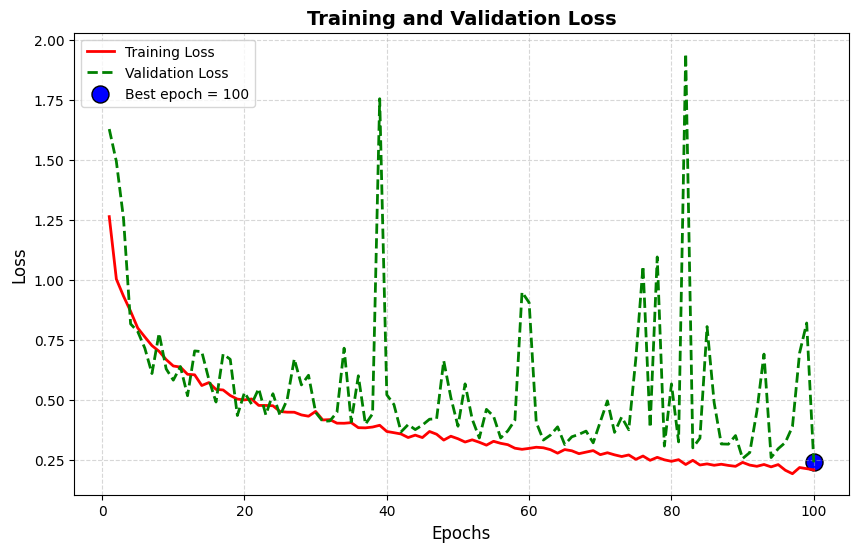

In [28]:
best_epoch_loss = np.argmin(val_loss)
best_val_loss = val_loss[best_epoch_loss]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_loss, color='red', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, color='green', label='Validation Loss', linestyle='--', linewidth=2)
plt.scatter(best_epoch_loss + 1, best_val_loss, s=150, c='blue',
            label=f'Best epoch = {best_epoch_loss + 1}', edgecolors='black')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

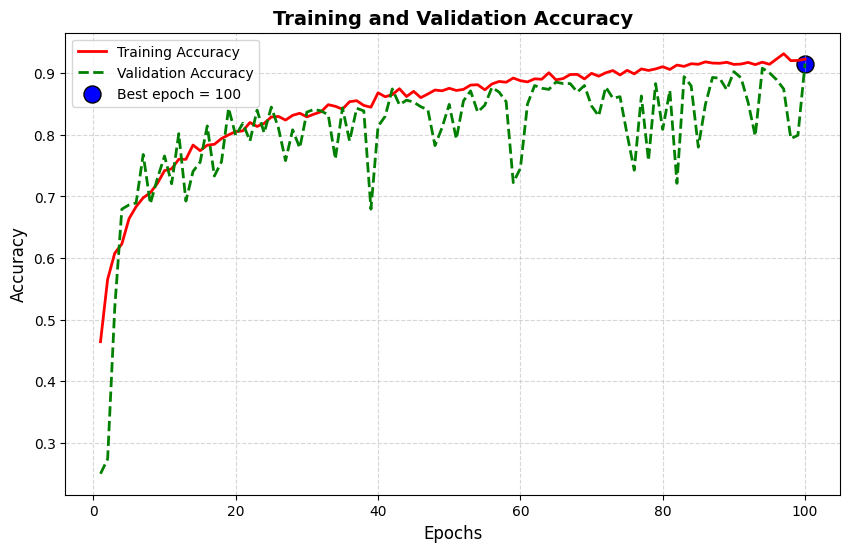

In [29]:
best_epoch_acc = np.argmax(val_acc)
best_val_acc = val_acc[best_epoch_acc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_acc, color='red', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, color='green', label='Validation Accuracy', linestyle='--', linewidth=2)
plt.scatter(best_epoch_acc + 1, best_val_acc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_acc + 1}', edgecolors='black')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


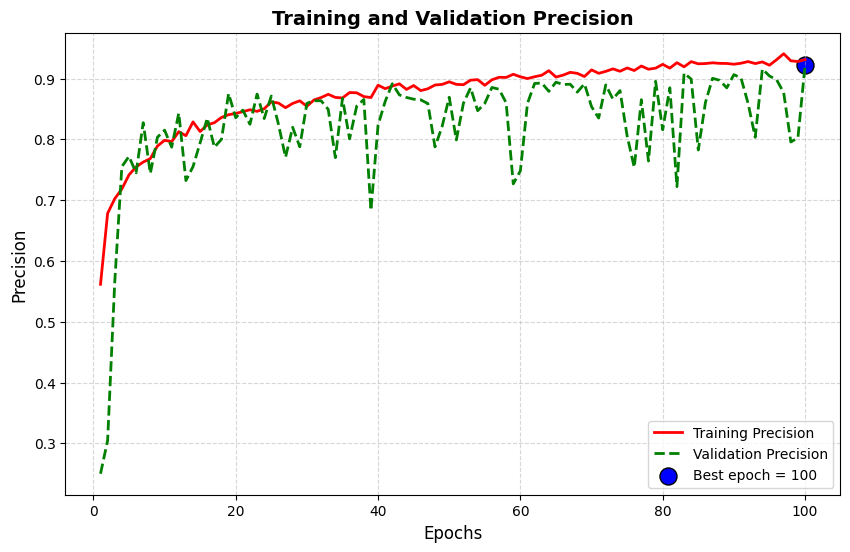

In [30]:
best_epoch_prec = np.argmax(val_precision)
best_val_prec = val_precision[best_epoch_prec]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_precision, color='red', label='Training Precision', linewidth=2)
plt.plot(epochs, val_precision, color='green', label='Validation Precision', linestyle='--', linewidth=2)
plt.scatter(best_epoch_prec + 1, best_val_prec, s=150, c='blue',
            label=f'Best epoch = {best_epoch_prec + 1}', edgecolors='black')
plt.title('Training and Validation Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


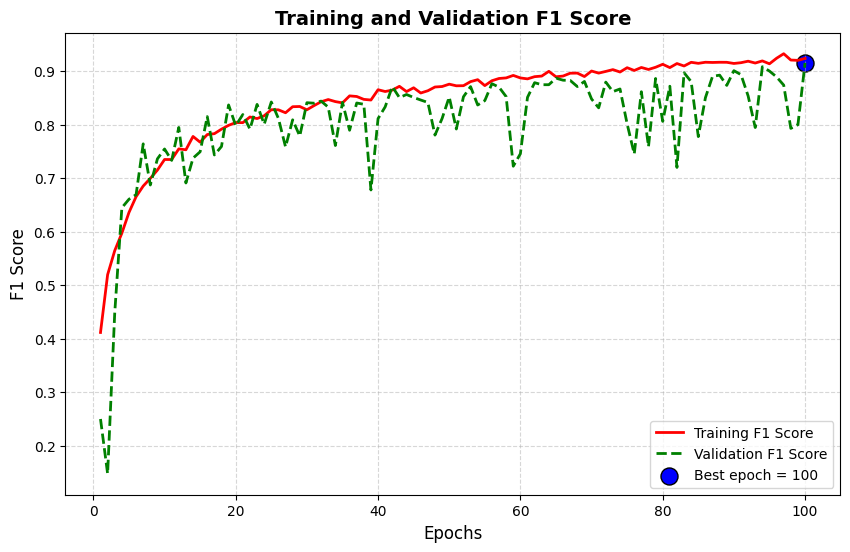

In [31]:
best_epoch_f1 = np.argmax(val_f1)
best_val_f1 = val_f1[best_epoch_f1]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_f1, color='red', label='Training F1 Score', linewidth=2)
plt.plot(epochs, val_f1, color='green', label='Validation F1 Score', linestyle='--', linewidth=2)
plt.scatter(best_epoch_f1 + 1, best_val_f1, s=150, c='blue',
            label=f'Best epoch = {best_epoch_f1 + 1}', edgecolors='black')
plt.title('Training and Validation F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

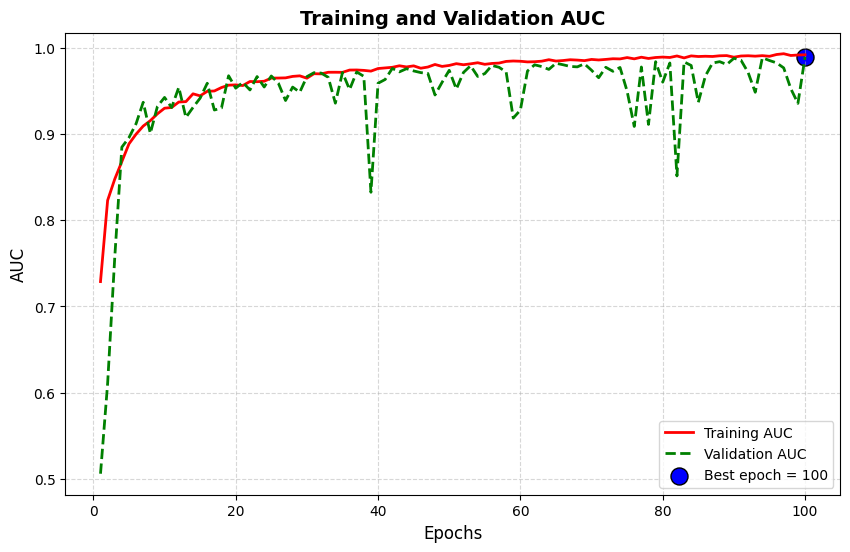

In [32]:
best_epoch_auc = np.argmax(val_auc)
best_val_auc = val_auc[best_epoch_auc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_auc, color='red', label='Training AUC', linewidth=2)
plt.plot(epochs, val_auc, color='green', label='Validation AUC', linestyle='--', linewidth=2)
plt.scatter(best_epoch_auc + 1, best_val_auc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_auc + 1}', edgecolors='black')
plt.title('Training and Validation AUC', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

In [33]:
def evaluate_model(model, test_data, labels, model_name, test_dataframe, batch_size=BATCH_SIZE):
    """
    Evaluate a trained Keras model using a test data generator.

    Args:
        model (Model): Trained Keras model.
        test_data (Iterator): A Keras data generator for testing.
        labels (List[str]): Class label names.
        model_name (str): Name of the model (for display).
        test_dataframe (pd.DataFrame): DataFrame with test samples (for step calculation).
        batch_size (int): Batch size used in the test_data generator.

    Returns:
        Tuple[dict, dict]: 
            - Dictionary containing accuracy, precision, recall, F1 score, and AUC.
            - Dictionary of AUC curve data {class_label: (fpr, tpr)} for ROC plotting.
    """

    # Calculate steps needed for full evaluation
    steps = math.ceil(len(test_dataframe) / batch_size)

    y_true = []
    y_pred = []
    y_probs = []

    # Loop through batches and collect predictions and true labels
    for _ in tqdm(range(steps), desc=f"Evaluating {model_name}"):
        images, labels_batch = next(test_data)

        preds = model.predict(images, verbose=0)            # Predicted probabilities
        y_probs.extend(preds)                               # Save for AUC

        y_pred.extend(np.argmax(preds, axis=-1))            # Predicted class indices
        y_true.extend(np.argmax(labels_batch, axis=-1))     # True class indices

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    # Calculate performance metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    try:
        auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='weighted')
    except ValueError:
        auc = float('nan')

    # Generate classification report
    report = classification_report(y_true, y_pred, target_names=labels)

    # Print summary metrics
    print(f"--- {model_name} ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}\n")
    print("Classification Report:\n")
    print(report)

    # Plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=labels, yticklabels=labels,
        annot_kws={'size': 14}, cbar=True, linewidths=0.5, linecolor='gray',
        cbar_kws={'shrink': 0.8}
    )
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12, rotation=45 if len(labels) > 10 else 0)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

    # Compute ROC curve data per class
    auc_curve_data = {}
    try:
        for i, label in enumerate(labels):
            fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_probs[:, i])
            auc_curve_data[label] = (fpr, tpr)
    except Exception:
        auc_curve_data = {}

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc
    }, auc_curve_data


Evaluating Proposed_Model: 100%|██████████| 25/25 [00:14<00:00,  1.68it/s]


--- Proposed_Model ---
Accuracy : 0.9175
Precision: 0.9221
Recall   : 0.9175
F1 Score : 0.9183
AUC      : 0.9922

Classification Report:

              precision    recall  f1-score   support

      Benign       0.90      0.93      0.91       200
 Early Pre-B       0.83      0.93      0.88       200
       Pre-B       0.97      0.86      0.91       200
       Pro-B       0.99      0.95      0.97       200

    accuracy                           0.92       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.92      0.92      0.92       800



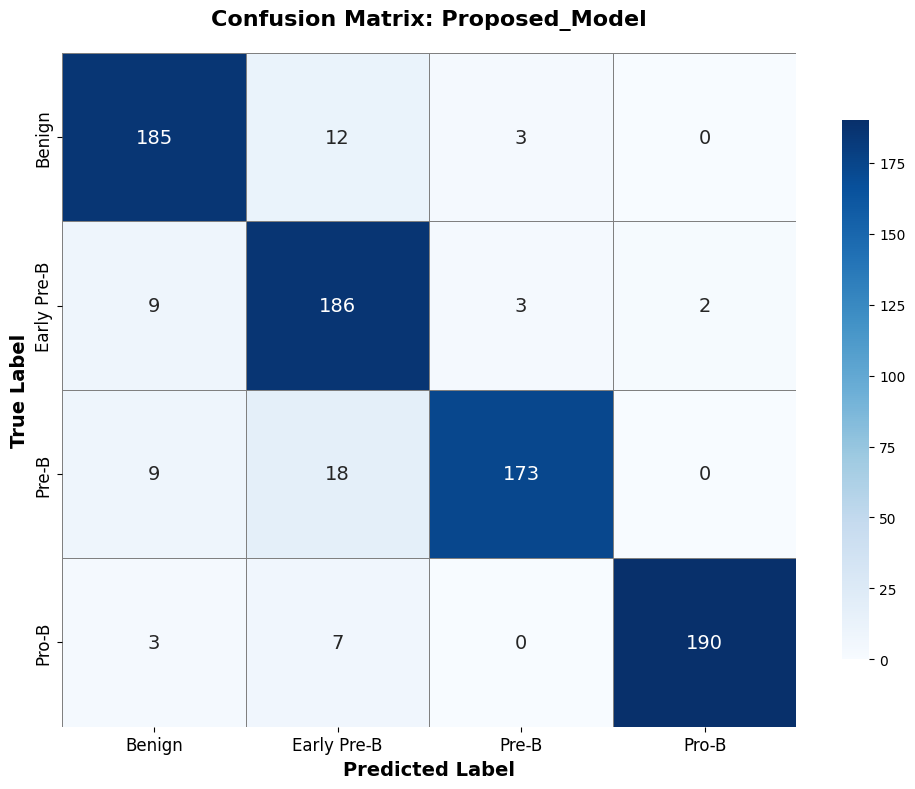

In [34]:
results, auc_curve_data = evaluate_model(model, test_data, labels, "Proposed_Model", test_dataframe)

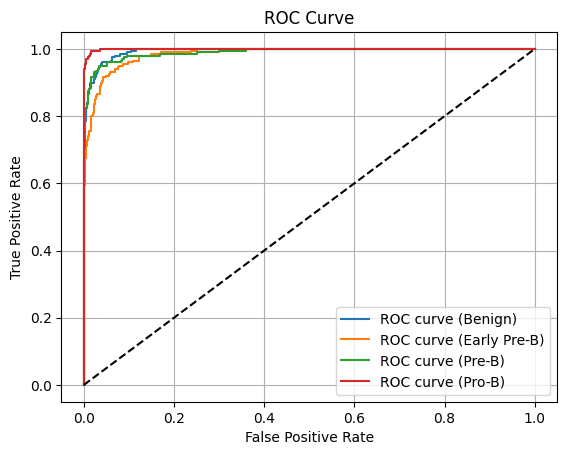

In [35]:
# Plotting the ROC curve
for label, (fpr, tpr) in auc_curve_data.items():
    plt.plot(fpr, tpr, label=f'ROC curve ({label})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

----------------
Bootstrap 95% Confidence interval


In [36]:
# -----------------------------
# Parameters
# -----------------------------
B = 1000                # number of bootstrap samples
RNG_SEED = 42

# 1) Get predictions and true labels
probs = model.predict(test_data, verbose=1)      # shape (N, num_classes)
y_true = np.asarray(test_data.classes)           # integer labels shape (N,)
num_classes = probs.shape[1]
y_pred = np.argmax(probs, axis=1)

# Point estimates
point_accuracy = accuracy_score(y_true, y_pred)
point_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
point_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
point_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
try:
    y_true_onehot = np.eye(num_classes)[y_true]
    point_auc = roc_auc_score(y_true_onehot, probs, multi_class='ovr', average='macro')
except Exception:
    point_auc = np.nan

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step


In [37]:
# 2) Bootstrap
rng = np.random.RandomState(RNG_SEED)
metrics_boot = {k: [] for k in ["accuracy", "precision", "recall", "f1", "auc"]}
N = len(y_true)

for i in tqdm(range(B), desc="Bootstrap samples"):
    idx = rng.randint(0, N, size=N)   # sample with replacement
    y_true_b, y_pred_b, probs_b = y_true[idx], y_pred[idx], probs[idx]

    metrics_boot["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    metrics_boot["precision"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["recall"].append(recall_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["f1"].append(f1_score(y_true_b, y_pred_b, average='macro', zero_division=0))

    try:
        y_true_b_onehot = np.eye(num_classes)[y_true_b]
        auc_b = roc_auc_score(y_true_b_onehot, probs_b, multi_class='ovr', average='macro')
    except Exception:
        auc_b = np.nan
    metrics_boot["auc"].append(auc_b)

# Convert lists to arrays
for k in metrics_boot:
    metrics_boot[k] = np.array(metrics_boot[k], dtype=np.float32)

Bootstrap samples: 100%|██████████| 1000/1000 [00:05<00:00, 167.71it/s]


In [38]:
# 3) Compute 95% CI
def ci95(arr):
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return (np.nan, np.nan)
    return np.percentile(arr, [2.5, 97.5])

results = []
for name, point in [
    ("accuracy", point_accuracy),
    ("precision", point_precision),
    ("recall", point_recall),
    ("f1", point_f1),
    ("auc", point_auc)
]:
    lo, hi = ci95(metrics_boot[name])
    results.append({
        "metric": name,
        "point_estimate": point,
        "ci_lower": lo,
        "ci_upper": hi,
        "n_boot_valid": int(np.sum(~np.isnan(metrics_boot[name])))
    })

df_results = pd.DataFrame(results).set_index("metric")
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results)

           point_estimate  ci_lower  ci_upper  n_boot_valid
metric                                                     
accuracy           0.9175    0.8963    0.9362          1000
precision          0.9221    0.9031    0.9398          1000
recall             0.9175    0.8973    0.9366          1000
f1                 0.9183    0.8978    0.9368          1000
auc                0.9922    0.9890    0.9950          1000


In [39]:
def plot_bootstrap_metrics(metrics_boot, df_results, n_cols=3, figsize_per_plot=(5, 4),
                           w_pad=0.6, h_pad=1.5, shift_factor=0.5):
    """
    Plot bootstrap metric distributions.

    Args:
        metrics_boot: dict of metric -> bootstrap array
        df_results: DataFrame with point estimates and CIs
        n_cols: 
            >0 -> number of columns for grid layout
             0 -> plot each metric separately (one figure per metric)
        figsize_per_plot: (width, height) per subplot
        w_pad: horizontal gap between subplots (grid mode only)
        h_pad: vertical gap between subplots (grid mode only)
        shift_factor: how much to center last row if not full (grid mode only)
    """

    metrics = list(metrics_boot.keys())
    n_metrics = len(metrics)

    # --------------------
    # Single-plot mode
    # --------------------
    if n_cols == 0:
        for metric in metrics:
            vals = metrics_boot[metric]
            vals_nonan = vals[~np.isnan(vals)]

            fig, ax = plt.subplots(figsize=figsize_per_plot)
            ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
            ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
            ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
            ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

            ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
            ax.legend()
            plt.tight_layout()
            plt.show()
        return  # done

    # --------------------
    # Grid mode
    # --------------------
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_per_plot[0]*n_cols,
                                      figsize_per_plot[1]*n_rows))
    axes = np.array(axes).reshape(-1)  # flatten

    for i, metric in enumerate(metrics):
        ax = axes[i]
        vals = metrics_boot[metric]
        vals_nonan = vals[~np.isnan(vals)]

        ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
        ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
        ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
        ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

        ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
        ax.legend()

        # 🔹 Format x-axis ticks to 2 decimal places
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))

    # remove unused axes
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    # ---- Center last row if it's not full ----
    last_row_count = n_metrics % n_cols
    if last_row_count != 0:
        empty_slots = n_cols - last_row_count
        last_row_axes = axes[n_cols*(n_rows-1):n_cols*(n_rows-1)+last_row_count]

        for ax in last_row_axes:
            pos = ax.get_position()
            shift = (empty_slots / n_cols) * shift_factor
            pos_new = [pos.x0 + shift, pos.y0, pos.width, pos.height]
            ax.set_position(pos_new)

    plt.tight_layout(pad=1.0, w_pad=w_pad, h_pad=h_pad)
    plt.show()

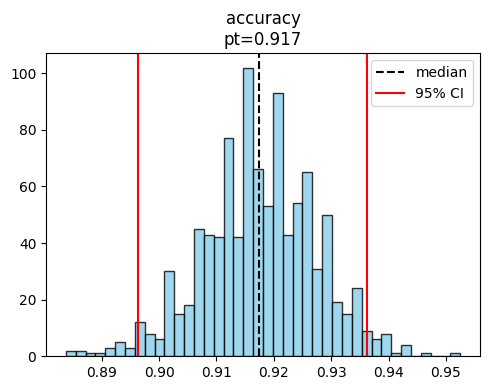

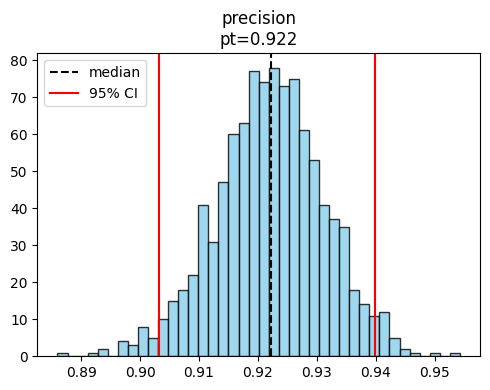

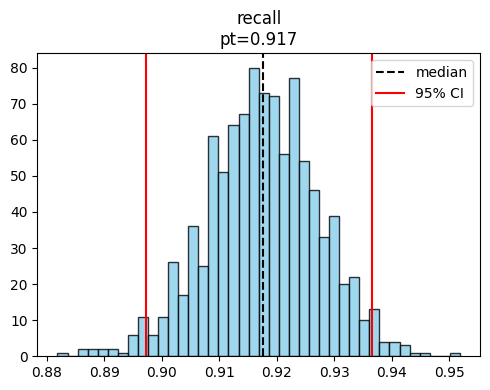

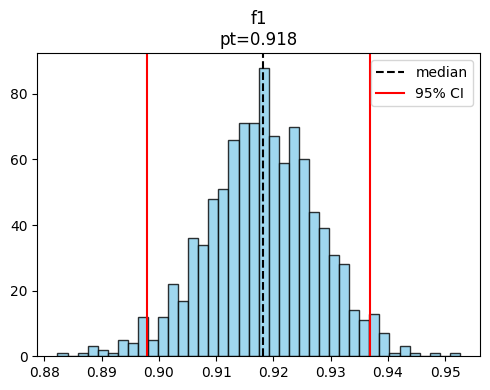

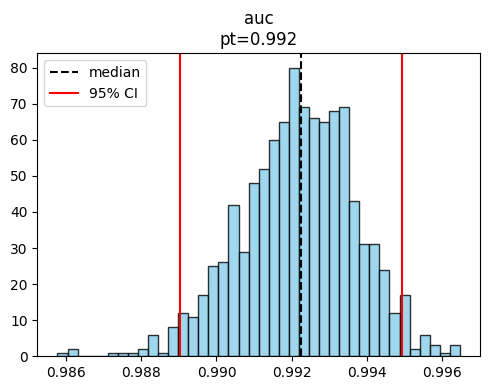

In [40]:
plot_bootstrap_metrics(
    metrics_boot, 
    df_results, 
    n_cols=0,        # number of columns in grid (set 0 for separate plots, 2 or 3 for grid)
    w_pad=0.5,       # horizontal space between columns (increase -> wider gap)
    h_pad=1.0,       # vertical space between rows (increase -> taller gap)
    shift_factor=0.0 # how much to horizontally shift last-row plots for centering
)


--------------------
Gradcam ++ (more advance visualization than previous version of mine)

In [41]:
kan1 = model.get_layer(index=-3)   # KANLayer with 64 units
kan2 = model.get_layer(index=-2)   # KANLayer with 32 units

In [42]:
for layer in [kan1, kan2]:
    print("Layer:", layer.name)
    for w in layer.weights:
        print(w.name, w.shape)

Layer: kan_layer
linear_weight (512, 64)
spline_weight (5, 512, 64)
bias (64,)
Layer: kan_layer_1
linear_weight (64, 32)
spline_weight (5, 64, 32)
bias (32,)


In [43]:
plt.style.use('seaborn-v0_8-whitegrid')

# ============================================================================
# 1. MATHEMATICAL KAN EXPLAINER
# ============================================================================

class MathematicalKANExplainer:
    """Visualize KAN layers as mathematical functions"""
    
    def __init__(self, model):
        self.model = model
        self.kan_layers = {}
        
        for layer in model.layers:
            if 'KAN' in layer.__class__.__name__:
                self.kan_layers[layer.name] = layer
        
        print(f"✓ Found {len(self.kan_layers)} KAN layers")

    def extract_kan_functions(self, layer_name=None):
        """Extract all learned functions from KAN layer"""
        if layer_name is None:
            layer_name = list(self.kan_layers.keys())[0]
        
        layer = self.kan_layers[layer_name]
        weights = layer.get_weights()
        
        linear_w = weights[0]
        spline_w = weights[1]
        bias = weights[2]
        
        return {
            'linear_w': linear_w,
            'spline_w': spline_w,
            'bias': bias,
            'grid': layer.grid,
            'layer_name': layer_name,
            'input_dim': linear_w.shape[0],
            'output_dim': linear_w.shape[1]
        }

    def visualize_mathematical_functions(self, layer_name=None, feature_idx=0, 
                                        num_outputs=4, figsize=(16, 12)):
        """Visualize learned mathematical functions"""
        kan_funcs = self.extract_kan_functions(layer_name)
        
        linear_w = kan_funcs['linear_w']
        spline_w = kan_funcs['spline_w']
        bias = kan_funcs['bias']
        grid = kan_funcs['grid']
        
        x_range = np.linspace(0, 1, 500)
        x_grid = np.linspace(0, 1, grid)
        basis = np.exp(-np.square(x_range[:, np.newaxis] - x_grid[np.newaxis, :]))
        
        num_outputs = min(num_outputs, kan_funcs['output_dim'])
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        fig.suptitle(
            f'KAN Layer Mathematical Functions\n'
            f'{kan_funcs["layer_name"]}: Feature {feature_idx} -> Outputs',
            fontsize=16, fontweight='bold'
        )
        
        axes = axes.flatten()
        
        for output_idx in range(num_outputs):
            ax = axes[output_idx]
            
            w_linear = linear_w[feature_idx, output_idx]
            w_spline = spline_w[:, feature_idx, output_idx]
            b = bias[output_idx]
            
            y_linear = x_range * w_linear
            y_spline = basis @ w_spline
            y_total = y_linear + y_spline + b
            
            ax.plot(x_range, y_total, 'r-', linewidth=3.5, label='Total', zorder=5)
            ax.plot(x_range, y_linear, 'b--', linewidth=2, alpha=0.7, label='Linear')
            ax.plot(x_range, y_spline, 'g--', linewidth=2, alpha=0.7, label='Spline')
            ax.fill_between(x_range, y_total, alpha=0.15, color='red', zorder=2)
            
            for i, (x_center, w) in enumerate(zip(x_grid, w_spline)):
                ax.scatter([x_center], [w], s=150, color='darkred', zorder=4, 
                          edgecolors='black', linewidth=1.5)
            
            ax.axhline(0, color='k', linestyle='-', alpha=0.2, linewidth=0.8)
            ax.grid(True, alpha=0.3)
            ax.set_xlabel('Input x (normalized 0-1)', fontweight='bold', fontsize=11)
            ax.set_ylabel('Output f(x)', fontweight='bold', fontsize=11)
            
            eq_text = f"Output {output_idx}\n"
            eq_text += f"f(x) = {w_linear:.4f}*x + Σ(c_j*exp(-(x-μ_j)²)) + {b:.4f}"
            ax.set_title(eq_text, fontweight='bold', fontsize=10, family='monospace')
            
            ax.legend(loc='best', fontsize=10)
            ax.set_ylim([y_total.min() - 0.1, y_total.max() + 0.1])
        
        plt.tight_layout()
        return fig

    def visualize_feature_to_output_heatmap(self, layer_name=None, figsize=(12, 8)):
        """Heatmap: feature->output importance"""
        kan_funcs = self.extract_kan_functions(layer_name)
        
        linear_w = kan_funcs['linear_w']
        spline_w = kan_funcs['spline_w']
        
        linear_imp = np.abs(linear_w)
        spline_imp = np.sum(np.abs(spline_w), axis=0)
        importance_matrix = linear_imp + spline_imp
        
        importance_matrix = (importance_matrix - importance_matrix.min()) / (importance_matrix.max() - importance_matrix.min() + 1e-8)
        
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(importance_matrix.T, aspect='auto', cmap='hot', interpolation='nearest')
        
        ax.set_xlabel(f'Input Features (0-{kan_funcs["input_dim"]-1})', fontweight='bold', fontsize=12)
        ax.set_ylabel(f'Output Units (0-{kan_funcs["output_dim"]-1})', fontweight='bold', fontsize=12)
        ax.set_title(f'Feature->Output Importance Heatmap\n{kan_funcs["layer_name"]}', 
                    fontweight='bold', fontsize=14)
        
        plt.colorbar(im, ax=ax, label='Importance')
        plt.tight_layout()
        return fig

    def print_mathematical_summary(self, layer_name=None):
        """Print mathematical summary"""
        kan_funcs = self.extract_kan_functions(layer_name)
        
        print(f"\n{'='*80}")
        print(f"KAN LAYER MATHEMATICAL SUMMARY: {kan_funcs['layer_name']}")
        print(f"{'='*80}")
        print(f"Architecture: {kan_funcs['input_dim']} inputs -> {kan_funcs['output_dim']} outputs")
        print(f"Spline basis: {kan_funcs['grid']} RBF functions per feature")
        print(f"\nEach output: y_i = Σ_j (w_ij*x_j + Σ_k c_ijk*exp(-(x_j-μ_k)²)) + b_i")
        print(f"{'='*80}\n")

In [44]:
# ============================================================================
# 2. GRAD-CAM++ EXPLAINER
# ============================================================================

class GradCAMPlusPlus:
    """Grad-CAM++ for better attribution maps"""
    
    def __init__(self, model, target_layer, labels):
        self.model = model
        self.target_layer_name = target_layer
        self.labels = labels
        
        try:
            self.target_layer = model.get_layer(self.target_layer_name)
        except:
            print(f"❌ Layer '{self.target_layer_name}' not found!")
            print(f"Available Conv layers: {[l.name for l in model.layers if 'Conv' in l.__class__.__name__]}")
            raise
        
        print(f"✓ Grad-CAM++ initialized with layer: {self.target_layer_name}")

    def compute_gradcam_plus_plus(self, image, class_idx):
        """Compute Grad-CAM++ activation map"""
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        
        intermediate_model = Model(
            inputs=self.model.input,
            outputs=[self.target_layer.output, self.model.output]
        )
        
        with tf.GradientTape() as tape:
            layer_output, predictions = intermediate_model(img_tensor)
            tape.watch(layer_output)
            loss = predictions[0, class_idx]
        
        gradients = tape.gradient(loss, layer_output)
        
        if gradients is None:
            print("⚠️ Gradients None - using fallback")
            return self._compute_fallback_cam(image, class_idx, layer_output.numpy())
        
        layer_output_np = layer_output.numpy()[0]
        gradients_np = gradients.numpy()[0]
        
        second_deriv = np.power(gradients_np, 2)
        third_deriv = second_deriv * gradients_np
        
        alpha_denom = 2 * second_deriv + np.sum(third_deriv * layer_output_np, axis=(0, 1), keepdims=True)
        alpha_denom = np.where(alpha_denom != 0, alpha_denom, 1e-8)
        
        alpha = second_deriv / alpha_denom
        alpha = np.maximum(alpha, 0)
        
        weights = np.sum(alpha * np.maximum(gradients_np, 0), axis=(0, 1))
        weights = weights / (np.sum(weights) + 1e-8)
        
        cam = np.zeros(layer_output_np.shape[:2])
        for i, w in enumerate(weights):
            cam += w * layer_output_np[:, :, i]
        
        cam = np.maximum(cam, 0)
        
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam

    def _compute_fallback_cam(self, image, class_idx, layer_output):
        """Fallback CAM computation"""
        layer_output = layer_output[0]
        weights = np.mean(np.abs(layer_output), axis=(0, 1))
        weights = weights / (np.sum(weights) + 1e-8)
        
        cam = np.zeros(layer_output.shape[:2])
        for i, w in enumerate(weights):
            cam += w * layer_output[:, :, i]
        
        cam = np.maximum(cam, 0)
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam

    def predict_and_explain(self, image):
        """Complete pipeline"""
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        
        preds = self.model.predict(img_tensor, verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        confidence = float(preds[pred_idx])
        
        gradcam = self.compute_gradcam_plus_plus(image, pred_idx)
        
        gradcam_resized = tf.image.resize(
            tf.expand_dims(gradcam, -1), image.shape[:2]
        ).numpy()[..., 0]
        
        return {
            'prediction': self.labels[pred_idx],
            'confidence': confidence,
            'gradcam': gradcam_resized,
            'preds': preds
        }

    def visualize_gradcam_plus_plus(self, image, figsize=(14, 4)):
        """Visualize Grad-CAM++ with proper overlay"""
        result = self.predict_and_explain(image)
        
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(f'Grad-CAM++: {result["prediction"]} ({result["confidence"]:.1%})',
                    fontsize=14, fontweight='bold')
        
        # Original image
        ax = axes[0]
        ax.imshow(np.clip(image * 255, 0, 255).astype(np.uint8))
        ax.set_title('Original Image', fontweight='bold')
        ax.axis('off')
        
        # Grad-CAM++ heatmap
        ax = axes[1]
        ax.imshow(np.clip(image * 255, 0, 255).astype(np.uint8), alpha=1.0)
        im = ax.imshow(result['gradcam'], cmap='jet', alpha=0.5)
        ax.set_title('Grad-CAM++ Heatmap', fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Blended overlay (NO BLACK!)
        ax = axes[2]
        img_normalized = image / 255.0 if image.max() > 1 else image
        heatmap_rgb = plt.cm.jet(result['gradcam'])[..., :3]
        alpha_blend = result['gradcam'][:, :, np.newaxis]
        overlay = (1 - alpha_blend) * img_normalized + alpha_blend * heatmap_rgb
        overlay = np.clip(overlay, 0, 1)
        
        ax.imshow(overlay)
        ax.set_title('Blended Overlay', fontweight='bold')
        ax.axis('off')
        
        plt.tight_layout()
        return fig


In [45]:
# ============================================================================
# 3. COMPLETE UNIFIED EXPLAINER
# ============================================================================

class CompleteKANExplainer:
    """All-in-one KAN explainability"""
    
    def __init__(self, model, target_conv_layer, labels):
        self.model = model
        self.labels = labels
        
        self.math_explainer = MathematicalKANExplainer(model)
        self.gradcam = GradCAMPlusPlus(model, target_conv_layer, labels)
    
    def explain_prediction(self, image, feature_idx=0, num_outputs=4):
        """Complete explanation"""
        
        print("\n" + "="*80)
        print("COMPLETE KAN EXPLAINABILITY ANALYSIS")
        print("="*80)
        
        print("\n1️⃣  Visualizing learned mathematical functions...")
        fig1 = self.math_explainer.visualize_mathematical_functions(
            feature_idx=feature_idx, num_outputs=num_outputs
        )
        
        print("2️⃣  Creating feature-output importance heatmap...")
        fig2 = self.math_explainer.visualize_feature_to_output_heatmap()
        
        print("3️⃣  Computing Grad-CAM++ attribution map...")
        fig3 = self.gradcam.visualize_gradcam_plus_plus(image)
        
        print("4️⃣  Mathematical summary:")
        self.math_explainer.print_mathematical_summary()
        
        print("✅ Complete explanation generated!")
        print("="*80 + "\n")
        
        return fig1, fig2, fig3



✓ Found 2 KAN layers
✓ Grad-CAM++ initialized with layer: activation_25

COMPLETE KAN EXPLAINABILITY ANALYSIS

1️⃣  Visualizing learned mathematical functions...
2️⃣  Creating feature-output importance heatmap...
3️⃣  Computing Grad-CAM++ attribution map...
4️⃣  Mathematical summary:

KAN LAYER MATHEMATICAL SUMMARY: kan_layer
Architecture: 512 inputs -> 64 outputs
Spline basis: 5 RBF functions per feature

Each output: y_i = Σ_j (w_ij*x_j + Σ_k c_ijk*exp(-(x_j-μ_k)²)) + b_i

✅ Complete explanation generated!



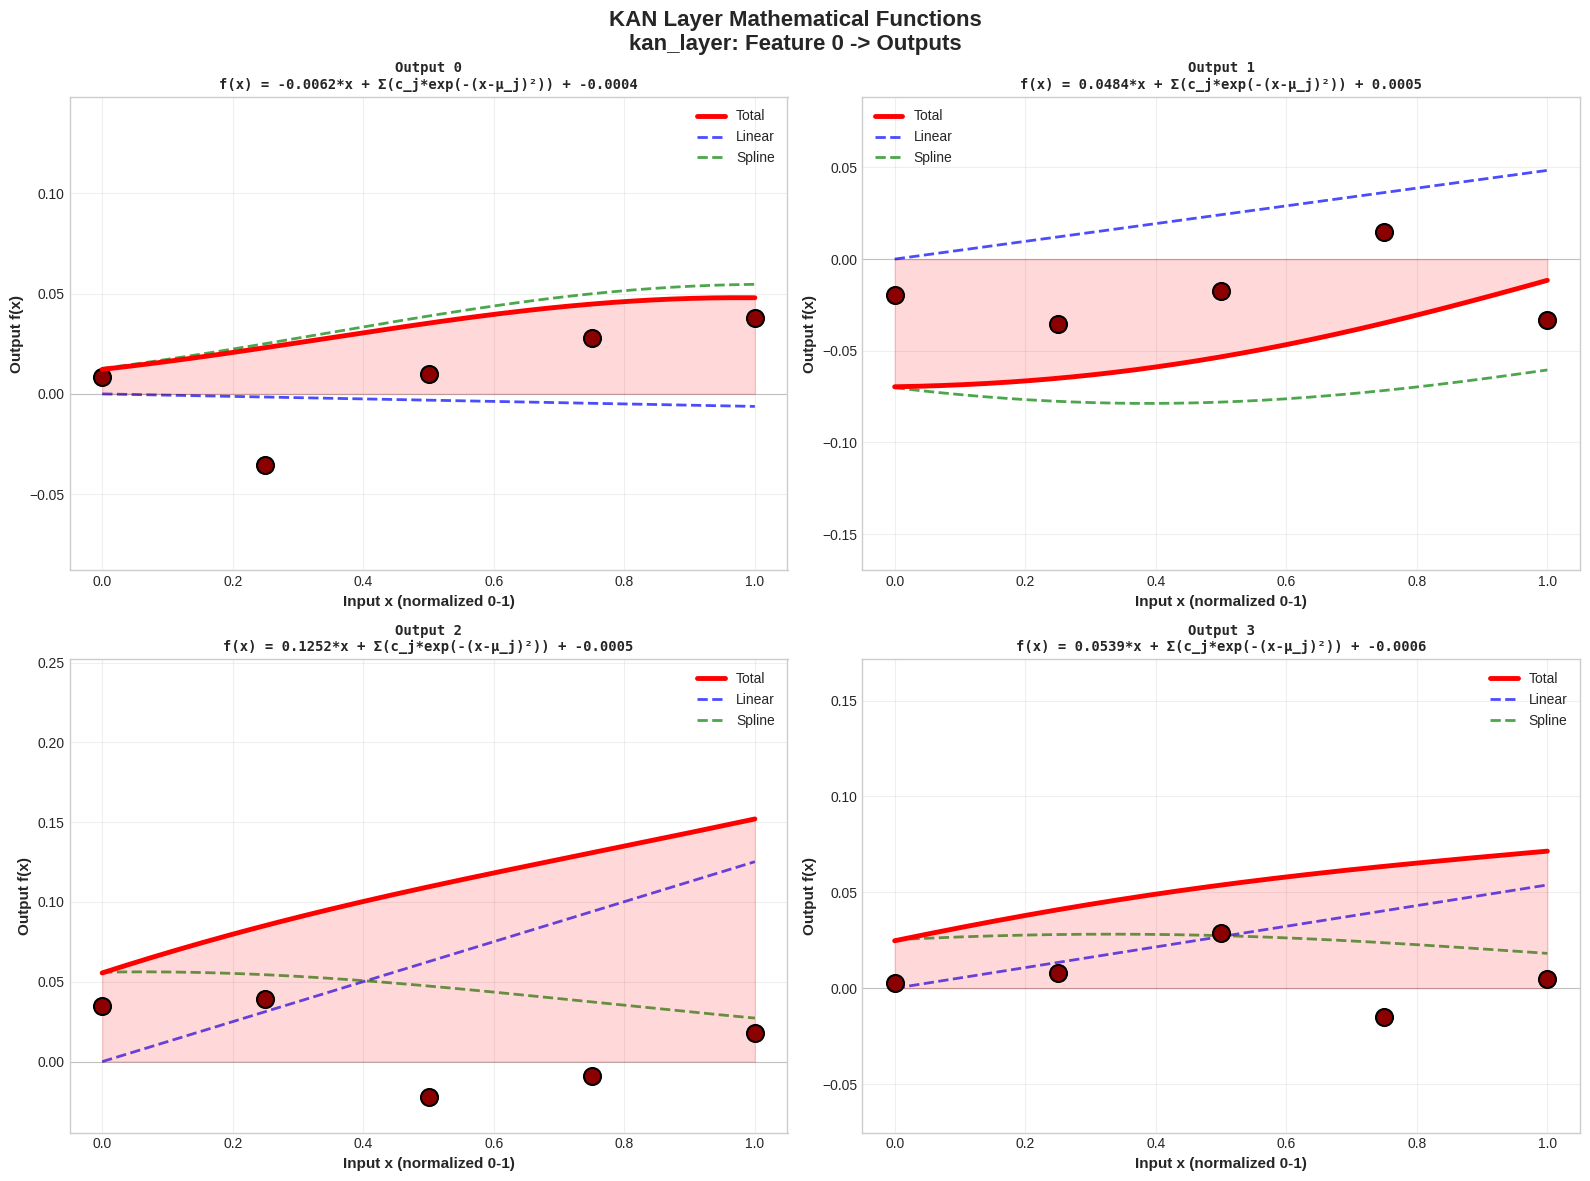

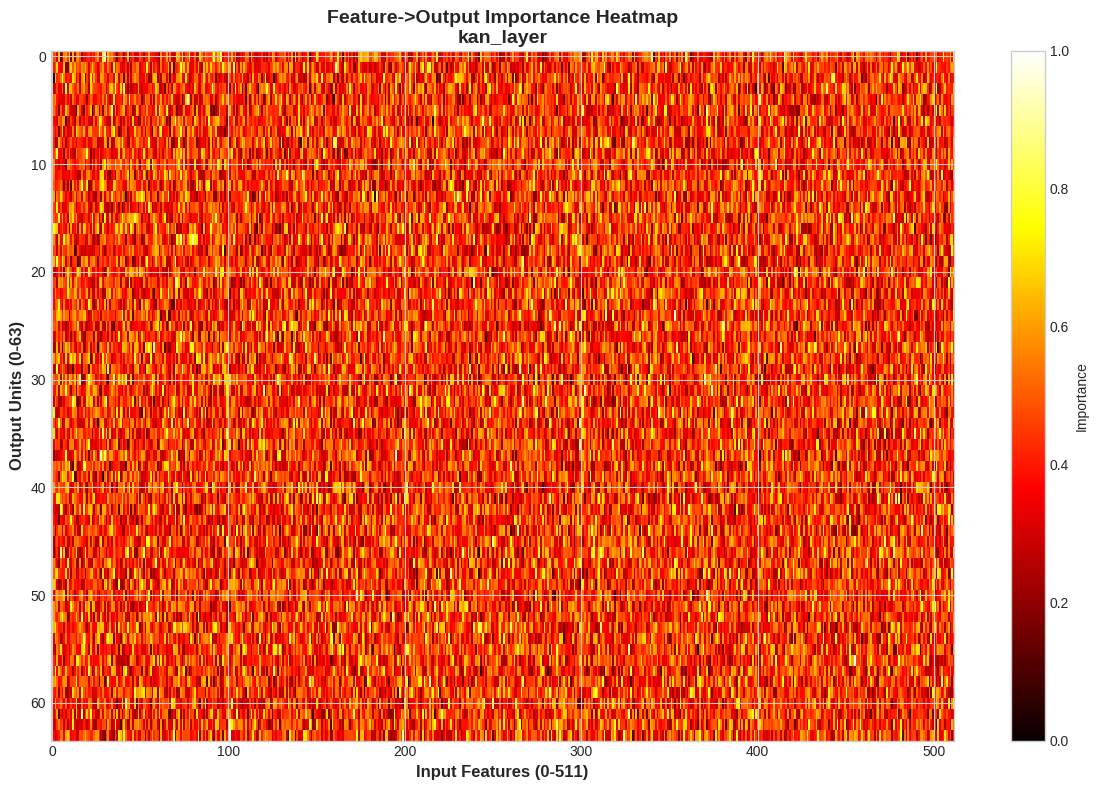

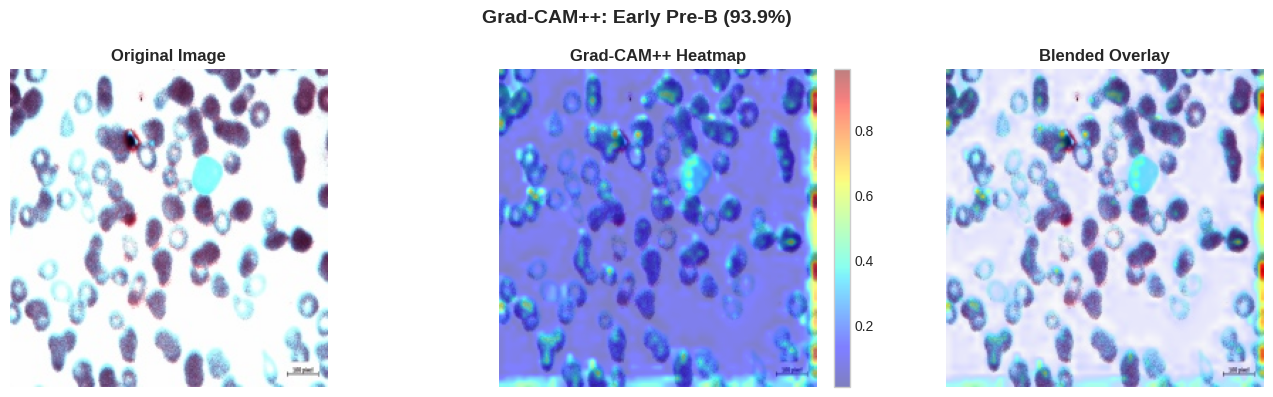

In [46]:
# ============================================================================
# USAGE
# ============================================================================

# Initialize
explainer = CompleteKANExplainer(
    model=model,
    target_conv_layer='activation_25',
    labels=labels
)

# Get test image
test_img, _ = test_data[0]
test_image = test_img[0]

# Generate all explanations
fig1, fig2, fig3 = explainer.explain_prediction(
    image=test_image,
    feature_idx=0,
    num_outputs=4
)

# Save
fig1.savefig('kan_mathematical_functions1.png', dpi=300, bbox_inches='tight')
fig2.savefig('feature_output_heatmap1.png', dpi=300, bbox_inches='tight')
fig3.savefig('gradcam_plus_plus1.png', dpi=300, bbox_inches='tight')

plt.show()


COMPLETE KAN EXPLAINABILITY ANALYSIS

1️⃣  Visualizing learned mathematical functions...
2️⃣  Creating feature-output importance heatmap...
3️⃣  Computing Grad-CAM++ attribution map...
4️⃣  Mathematical summary:

KAN LAYER MATHEMATICAL SUMMARY: kan_layer
Architecture: 512 inputs -> 64 outputs
Spline basis: 5 RBF functions per feature

Each output: y_i = Σ_j (w_ij*x_j + Σ_k c_ijk*exp(-(x_j-μ_k)²)) + b_i

✅ Complete explanation generated!



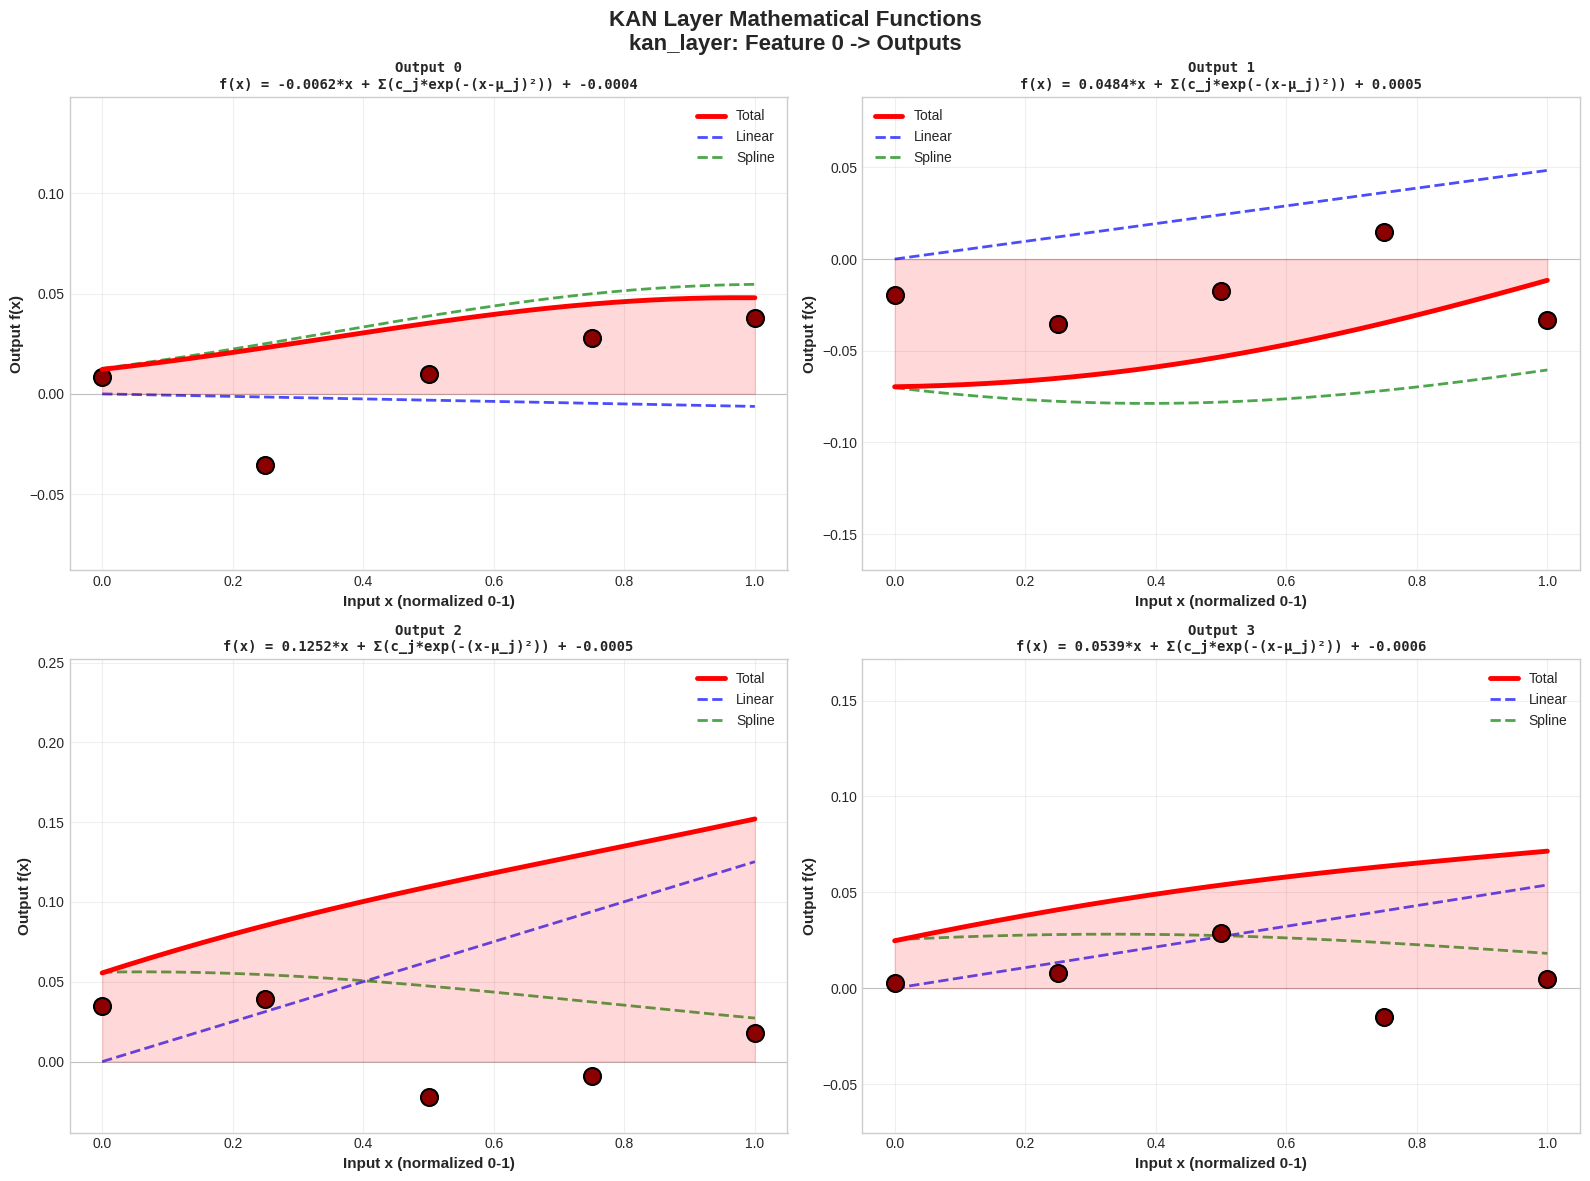

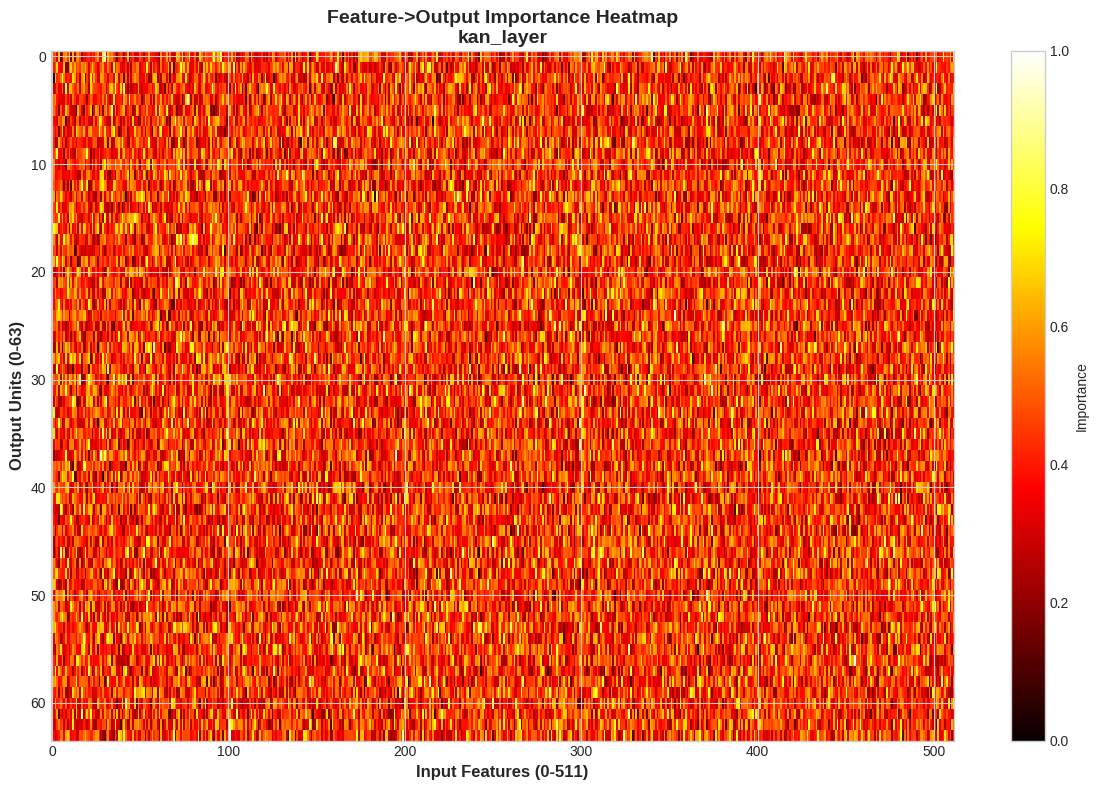

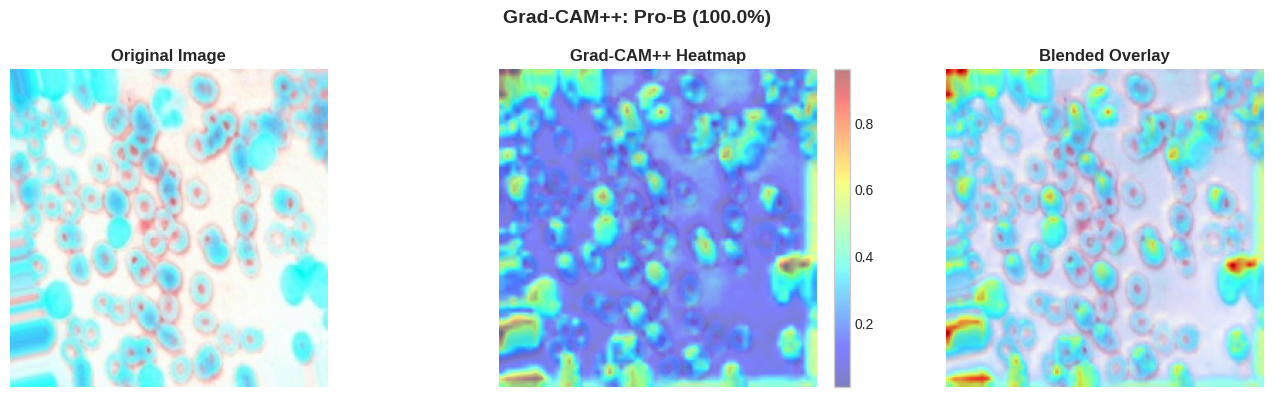

In [47]:
# Get test image
test_img, _ = test_data[1]
test_image = test_img[0]

# Generate all explanations
fig1, fig2, fig3 = explainer.explain_prediction(
    image=test_image,
    feature_idx=0,
    num_outputs=4
)

# Save
fig1.savefig('kan_mathematical_functions2.png', dpi=300, bbox_inches='tight')
fig2.savefig('feature_output_heatmap2.png', dpi=300, bbox_inches='tight')
fig3.savefig('gradcam_plus_plus2.png', dpi=300, bbox_inches='tight')

plt.show()


COMPLETE KAN EXPLAINABILITY ANALYSIS

1️⃣  Visualizing learned mathematical functions...
2️⃣  Creating feature-output importance heatmap...
3️⃣  Computing Grad-CAM++ attribution map...
4️⃣  Mathematical summary:

KAN LAYER MATHEMATICAL SUMMARY: kan_layer
Architecture: 512 inputs -> 64 outputs
Spline basis: 5 RBF functions per feature

Each output: y_i = Σ_j (w_ij*x_j + Σ_k c_ijk*exp(-(x_j-μ_k)²)) + b_i

✅ Complete explanation generated!



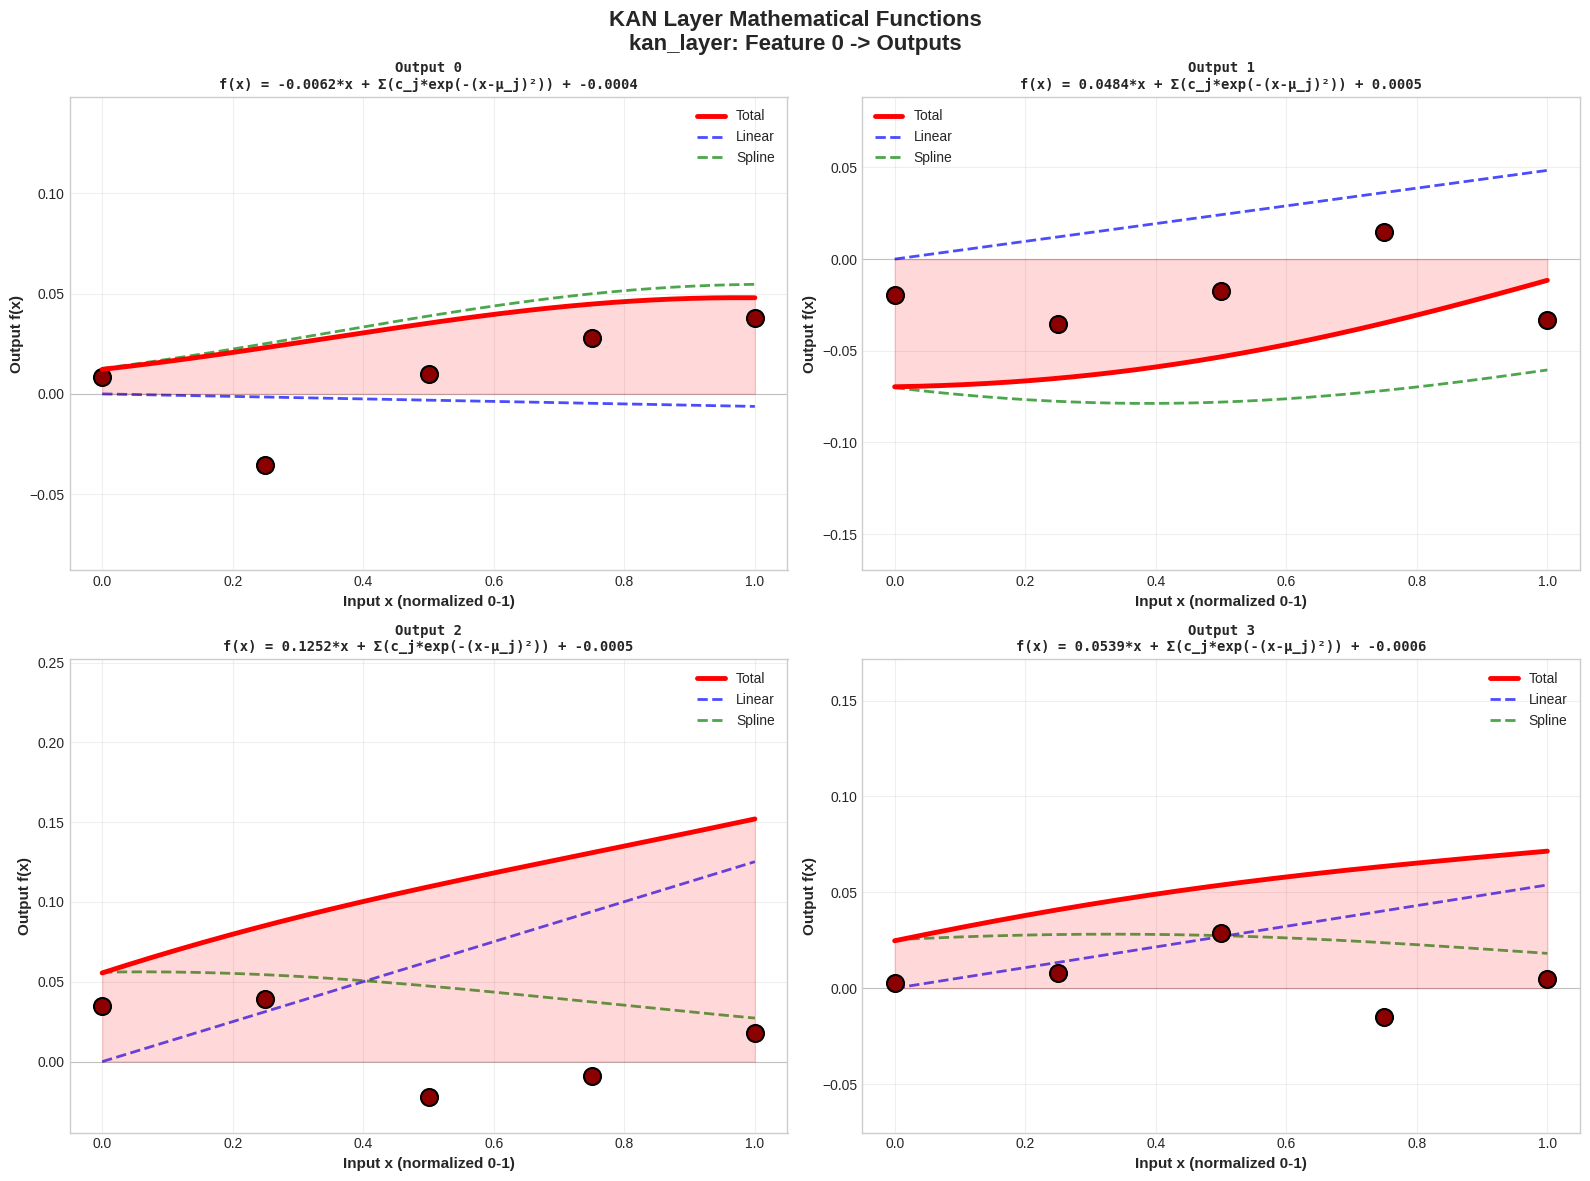

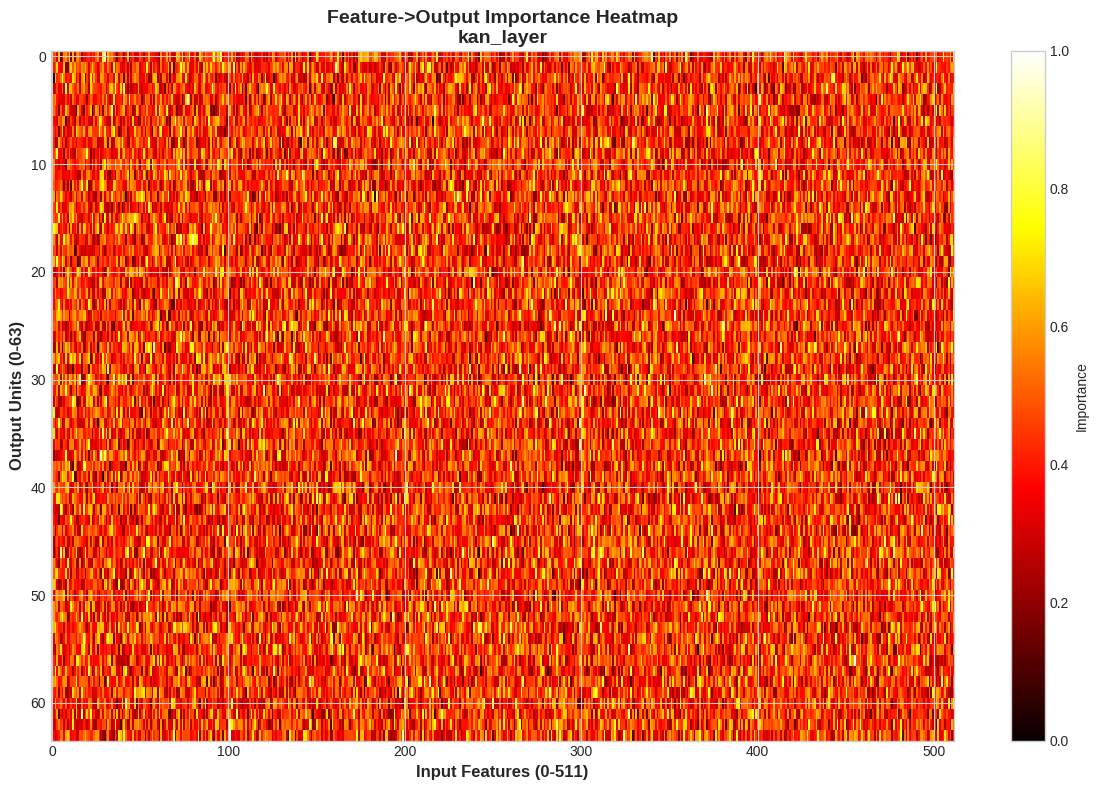

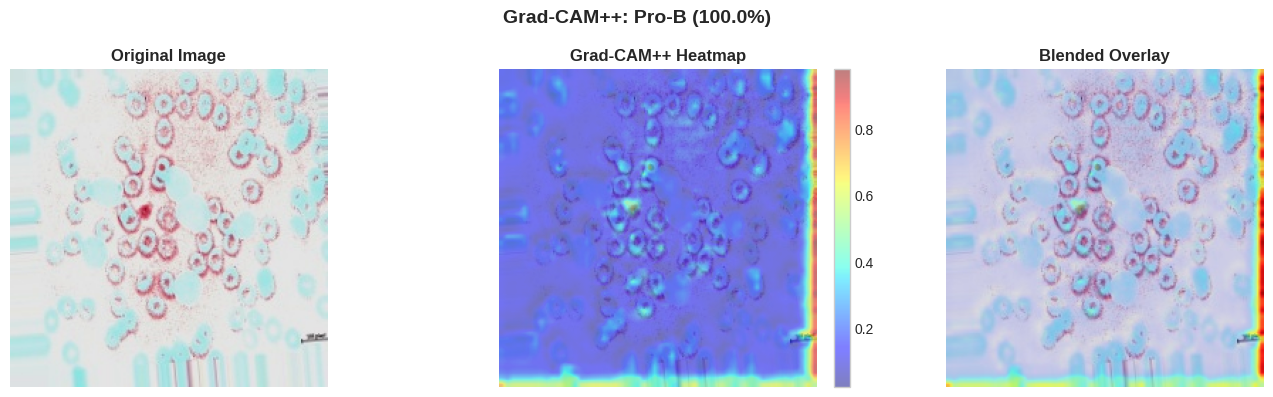

In [48]:
# Get test image
test_img, _ = test_data[2]
test_image = test_img[0]

# Generate all explanations
fig1, fig2, fig3 = explainer.explain_prediction(
    image=test_image,
    feature_idx=0,
    num_outputs=4
)

# Save
fig1.savefig('kan_mathematical_functions3.png', dpi=300, bbox_inches='tight')
fig2.savefig('feature_output_heatmap3.png', dpi=300, bbox_inches='tight')
fig3.savefig('gradcam_plus_plus3.png', dpi=300, bbox_inches='tight')

plt.show()

In [49]:
plot_model(model, show_shapes=True, show_layer_names=True, to_file="architecture.png")